## Setup Library

Sebelum mulai, alangkah baiknya mempersiapkan variable dan teman-temannya agar mudah untuk troubleshooting.

In [1]:
## Import dependencies
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.signal as signal

In [2]:
## Create faceDetector Object

## Define the models
base_model="v1/models/blaze_face_short_range.tflite"
base_options = python.BaseOptions(model_asset_path=base_model)

## Mediapipe configuration options
FaceDetectorOptions = vision.FaceDetectorOptions
VisionRunningMode = vision.RunningMode
options = FaceDetectorOptions(
    base_options=base_options,
    running_mode = VisionRunningMode.IMAGE,
)
face_detector = vision.FaceDetector.create_from_options(options)


## POS (Plane-Orthogonal to Skin)
Metode rPPG untuk mengambil sinyal denyut dari tubuh secara remote dengan menganalisis perubahan warna kulit, sederhananya mengambil warna yang dipancarkan kulit lalu di ubah menjadi sinyal fisiologis. 

Referensi.
- [Ref. Paper](https://pure.tue.nl/ws/files/31563684/TBME_00467_2016_R1_preprint.pdf)


In [3]:
## Core method POS 
def POS(signal, **kargs):
    """
    POS method on CPU using Numpy.

    The dictionary parameters are: {'fps':float}.

    Wang, W., den Brinker, A. C., Stuijk, S., & de Haan, G. (2016). Algorithmic principles of remote PPG. IEEE Transactions on Biomedical Engineering, 64(7), 1479-1491. 
    """
    """
    eps: A small constant (10^-9) used to prevent division by zero in normalization steps.
    X: The input signal, which is a 3D array where:
    e: Number of estimators or regions in the frame (like different parts of the face).
    c: Color channels (3 for RGB).
    f: Number of frames.
    w: Window length, determined by the camera's frame rate (fps). For example, at 20 fps, w would be 32 (which corresponds to about 1.6 seconds of video).
    """
    eps = 10**-9
    X = signal
    e, c, f = X.shape # Number of estimators, color channels, and frames
    w = int(1.6 * kargs['fps']) # Window length in frames

    """
    P: A fixed 2x3 matrix used for the projection step. It defines how to transform the color channels (RGB) into a new space.
    Q: This is a stack of the matrix P repeated e times, where each P corresponds to an estimator (region of interest) in the video.
    """
    P = np.array([[0, 1, -1], [-2, 1, 1]])
    Q = np.stack([P for _ in range(e)], axis = 0)

    """
    H: A matrix to store the estimated heart rate signal over time for each estimator.
    n: The current frame in the sliding window.
    m: The start index of the sliding window (calculating which frames are part of the current window).
    """
    H = np.zeros((e, f))
    for n in np.arange(w, f):
        # Start index of sliding window 
        m = n - w + 1

        """
        Temporal Normalization (Equation 5 from the paper): This step ensures that the signal is invariant to global lighting changes and other noise factors.
        """
        Cn = X[:, :, m:(n+1)]
        M = 1.0 / (np.mean(Cn, axis = 2) + eps)
        M = np.expand_dims(M, axis=2) # shape [e, c, w]
        Cn = np.multiply(Cn, M)

        """
        Projection (Equation 6 from the paper): This step transforms the RGB values into a space where the signal from blood flow (heart rate) is more distinct.
        """
        S = np.dot(Q, Cn)
        S = S[0, :, :, :]
        S = np.swapaxes(S, 0, 1) 

        """
        Tuning (Equation 7 from the paper): This step adjusts the projected components to make the heart rate signal clearer.
        """
        S1 = S[:, 0, :]
        S2 = S[:, 1, :]
        alpha = np.std(S1, axis=1) / (eps + np.std(S2, axis=1))
        alpha - np.expand_dims(alpha, axis=1)
        Hn = np.add(S1, alpha * S2)
        Hnm = Hn - np.expand_dims(np.mean(Hn, axis=1), axis=1)

        """
        Overlap-Adding (Equation 8 from the paper): This step combines the processed signals from each frame to form the final output heart rate signal.
        """
        H[:, m:(n + 1)] = np.add(H[:, m:(n + 1)], Hnm)  # Add the tuned signal to the output matrix

    return H

In [4]:
## Some variables, containers, constants and buffer
r_signal, g_signal, b_signal = [], [], [] ## For storing RGB value from the skin
fps = 35 ## Frame rate of the camera
time_window = 60 # Time window in seconds
frame_buffer_limit = time_window * fps ## Number of frames to be processed, since toby-rgb is 60 seconds
frame_buffer = [] ## Buffer for storing frames
margin_x = 10  # Adjust horizontally
scaling_factor = 0.8 # Scaling factor for the bounding box


### Main Method 📖

Tahapan ini cukup penting dalam proses pengubahan sinyal RGB kulit menjadi sinyal fisiologis tubuh. 

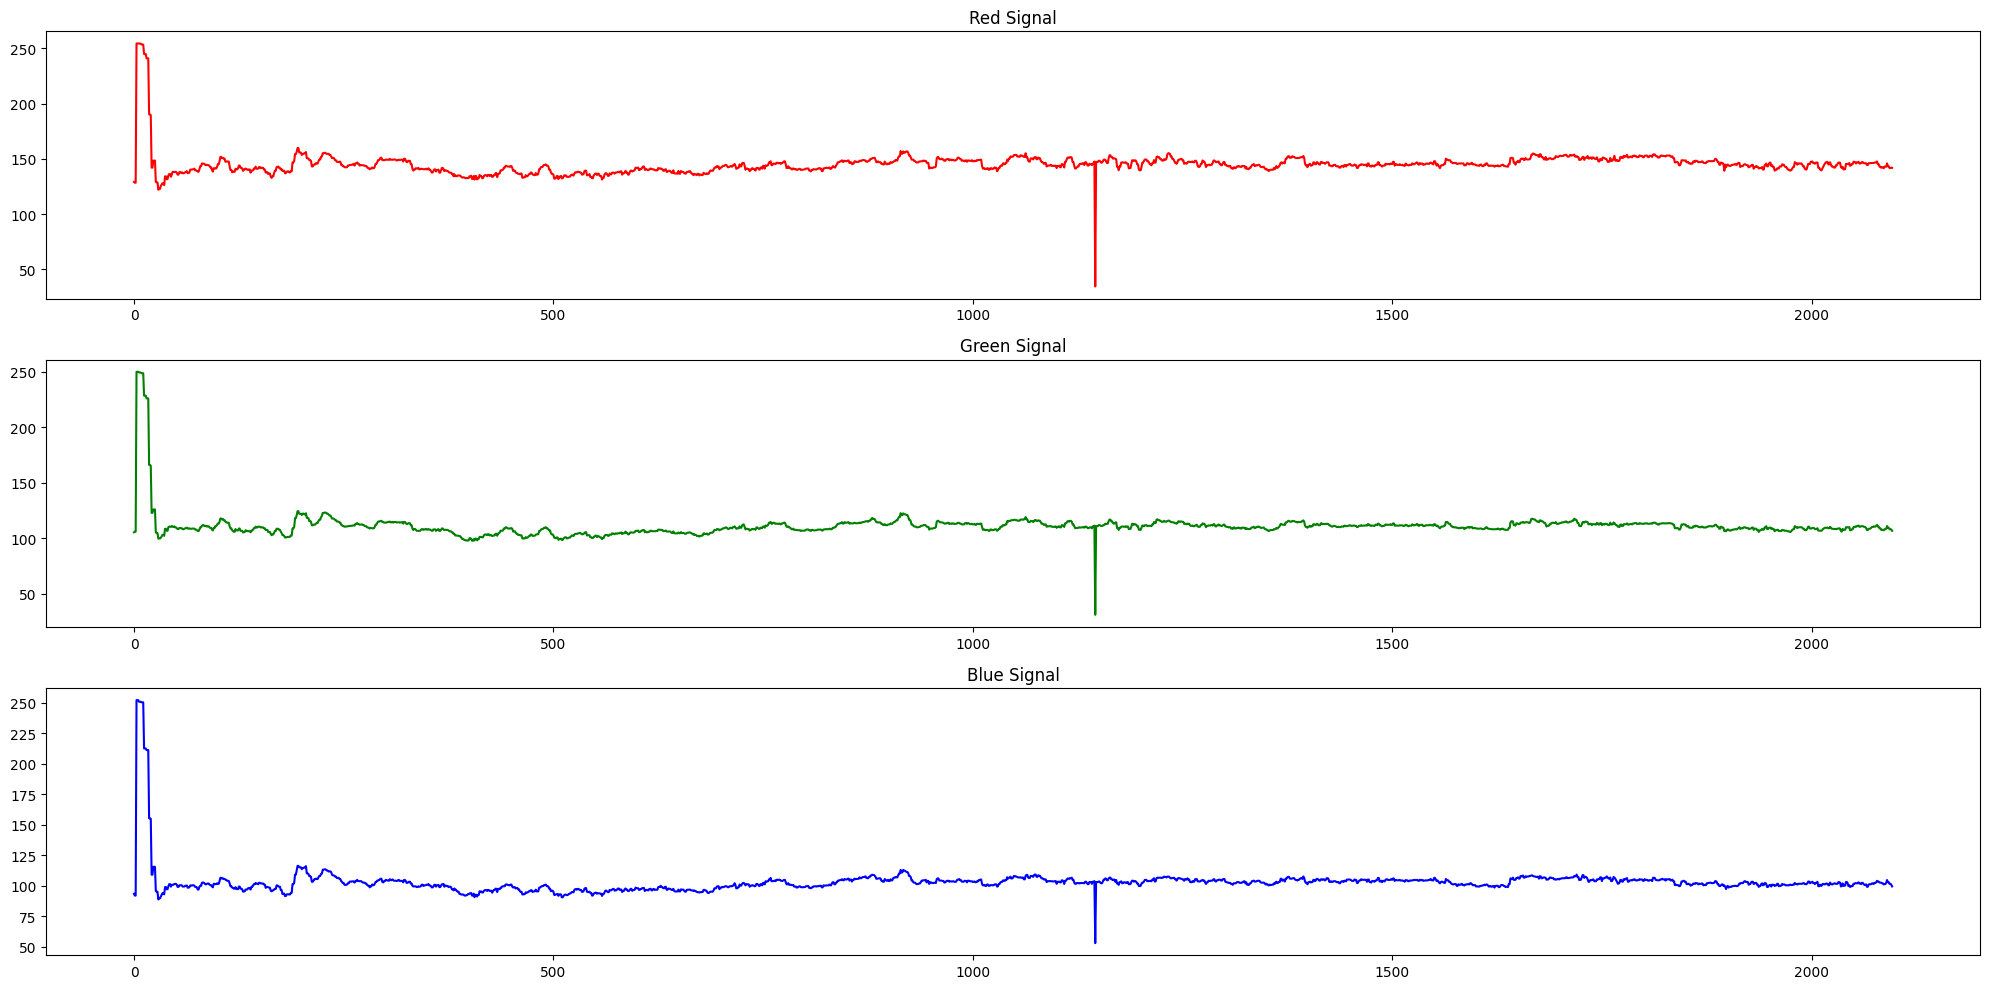

In [5]:
try:    
    ## Put 0 to use the camera, or use the video file path for analyzing a video
    cap = cv2.VideoCapture(1) 

    if not cap.isOpened():
        print("Error: Could not open video.")
        exit()

    ## Untuk mendapatkan 60 detik video.
    while len(frame_buffer) < frame_buffer_limit:

        ## Read the frame from the camera
        ret, frame = cap.read() 
        if not ret:
            print("Error: Could not read frame.")
            break

        ## Adding the frame_buffer to the list
        frame_buffer.append(frame)


        ## Convert the frame to RGB
        ## Karena default dari OpenCV adalah BGR, kita perlu mengkonversi ke RGB
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        ## Seting up the Mediapipe Image
        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb_frame
        )

        ## Process the frame using the face detector
        result = face_detector.detect(mp_image)

        """
        Where the magic happens:

        Proses ini melakukan deteksi wajah pada frame video untuk mendapatkan bounding box wajah.
        Kemudian, bounding box ini digunakan untuk mendapatkan ROI (Region of Interest) dari wajah, yang kemudian digunakan 
        untuk menghitung nilai rata-rata RGB dari area tersebut. 

        Nilai rata-rata RGB ini disimpan dalam list r_signal, g_signal, dan b_signal untuk analisis lebih lanjut.
        """
        if result.detections:
            for detection in result.detections:

                ## Get the Bounding box
                bboxC = detection.bounding_box
                x, y, w, h = bboxC.origin_x, bboxC.origin_y, bboxC.width, bboxC.height

                ## Setup tipis tipis biar boxnya pas di tengah wajah
                new_x = int(x + margin_x)
                new_w = int(w * scaling_factor)
                new_h = int(h * scaling_factor)

                ## Get the ROI
                face_roi = rgb_frame[y:y+new_h, new_x:new_x+new_w]
            
                ## Draw the bounding box on the frame
                cv2.rectangle(frame, (int(x), int(y)), (int(x + new_w), int(y + new_h)), (0, 255, 0), 2)

                ## Calculate the Mean RGB values of the face ROI
                mean_rgb = cv2.mean(face_roi)[:3]
                
                # Append the combined RGB values to the respective lists
                r_signal.append(mean_rgb[0])
                g_signal.append(mean_rgb[1])
                b_signal.append(mean_rgb[2])

        # Show the frame
        cv2.imshow("frame", frame) 

        # Check if 'q' is pressed or the window is closed
        if cv2.waitKey(1) & 0xFF == ord('q') or cv2.getWindowProperty("frame", cv2.WND_PROP_VISIBLE) < 1:
            break
        
except Exception as e:
    print(f"An error occurred: {e}")
    cap.release()
    cv2.destroyAllWindows()

finally:
    ## Release the camera and close all windows
    cap.release()
    cv2.destroyAllWindows()

    ax, fig = plt.subplots(3, 1, figsize=(20, 10))
    fig[0].plot(r_signal, color='red')
    fig[0].set_title('Red Signal')
    fig[1].plot(g_signal, color='green')
    fig[1].set_title('Green Signal')
    fig[2].plot(b_signal, color='blue')
    fig[2].set_title('Blue Signal')
    plt.tight_layout()
    plt.show()


### Post-Processing rPPG signals
Sinyal yang diperoleh masih cukup raw (mentah), masih belum bisa dilakukan analisis lebih lanjut tanpa post-processing. 

Pada tahapan ini akan dilakukan post-processing untuk melakukan filtering sinyal dan menentukan peak dari sinyal yang merupkan tanda dari detak jantung.
\
Tahapan pertama yakni merubah sinyal RGB menjadi rPPG

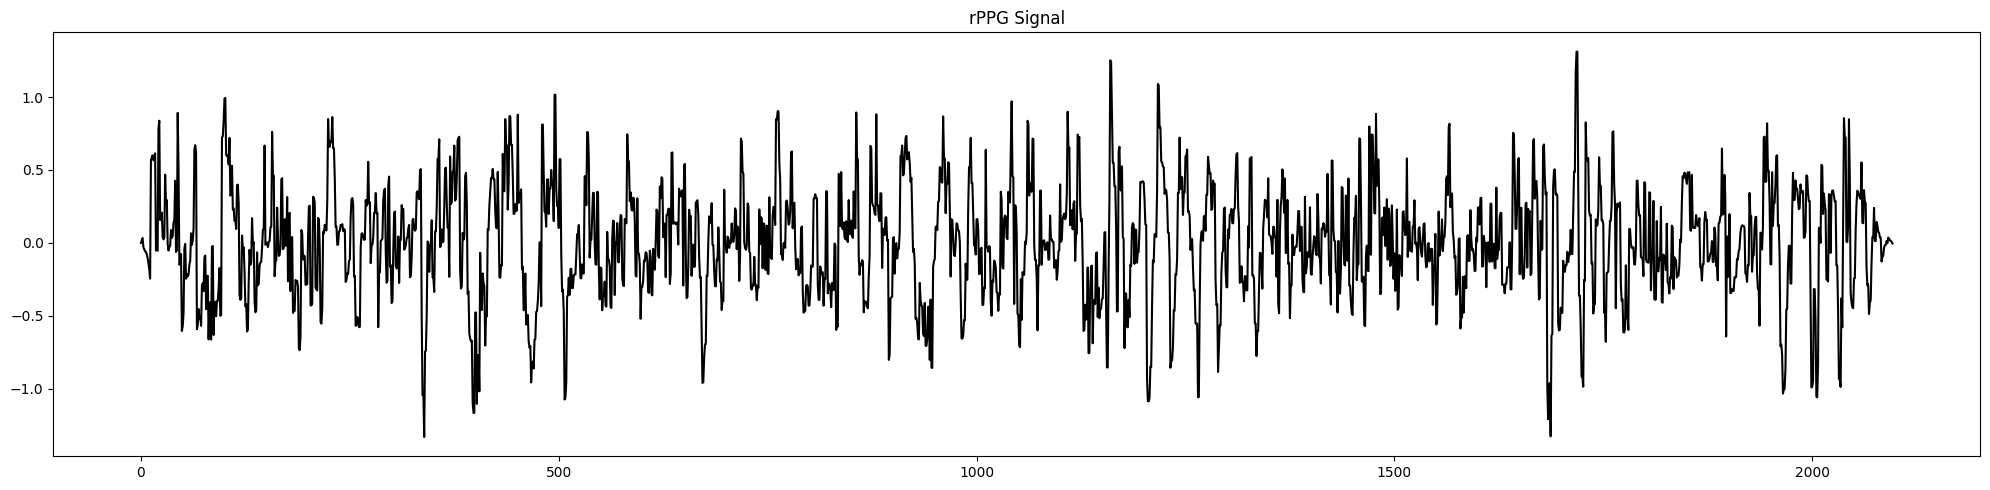

In [6]:
# Menghitung rPPG menggunakan Metode POS
rgb_signals = np.array([r_signal, g_signal, b_signal])
rgb_signals = rgb_signals.reshape(1, 3, -1)
rppg_signal = POS(rgb_signals, fps=30)
rppg_signal = rppg_signal.reshape(-1)

# 6.1 Menampilkan grafik Sinyal rPPG
plt.figure(figsize=(20, 5))
plt.plot(rppg_signal, color='black')
plt.title('rPPG Signal')
plt.tight_layout()
plt.show()

## Post-Processing dan Analysis 
Selanjutnya adalah tahapan filtering dan menentukan analisis menentukan peak / puncak dari sinyal

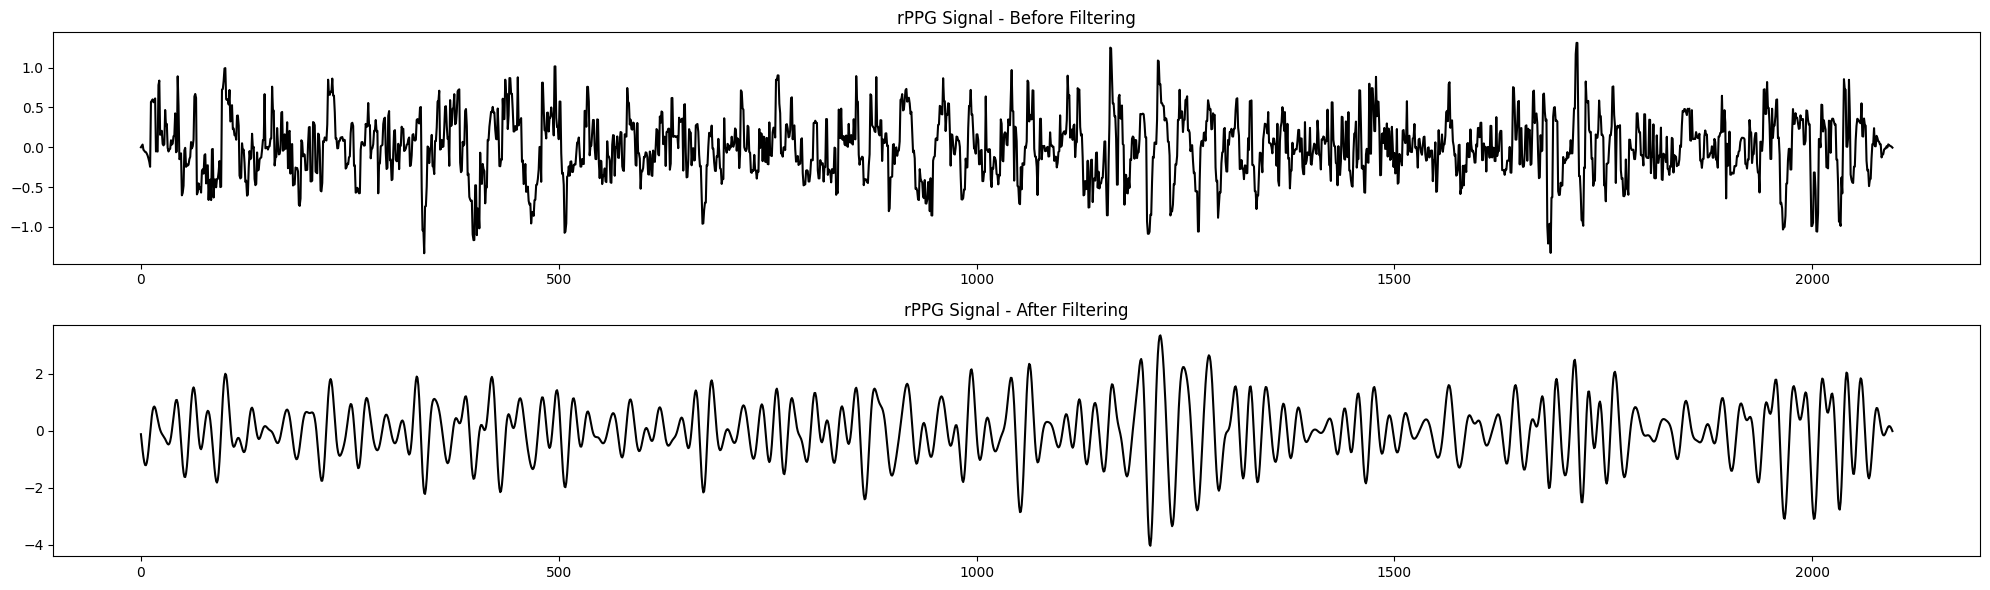

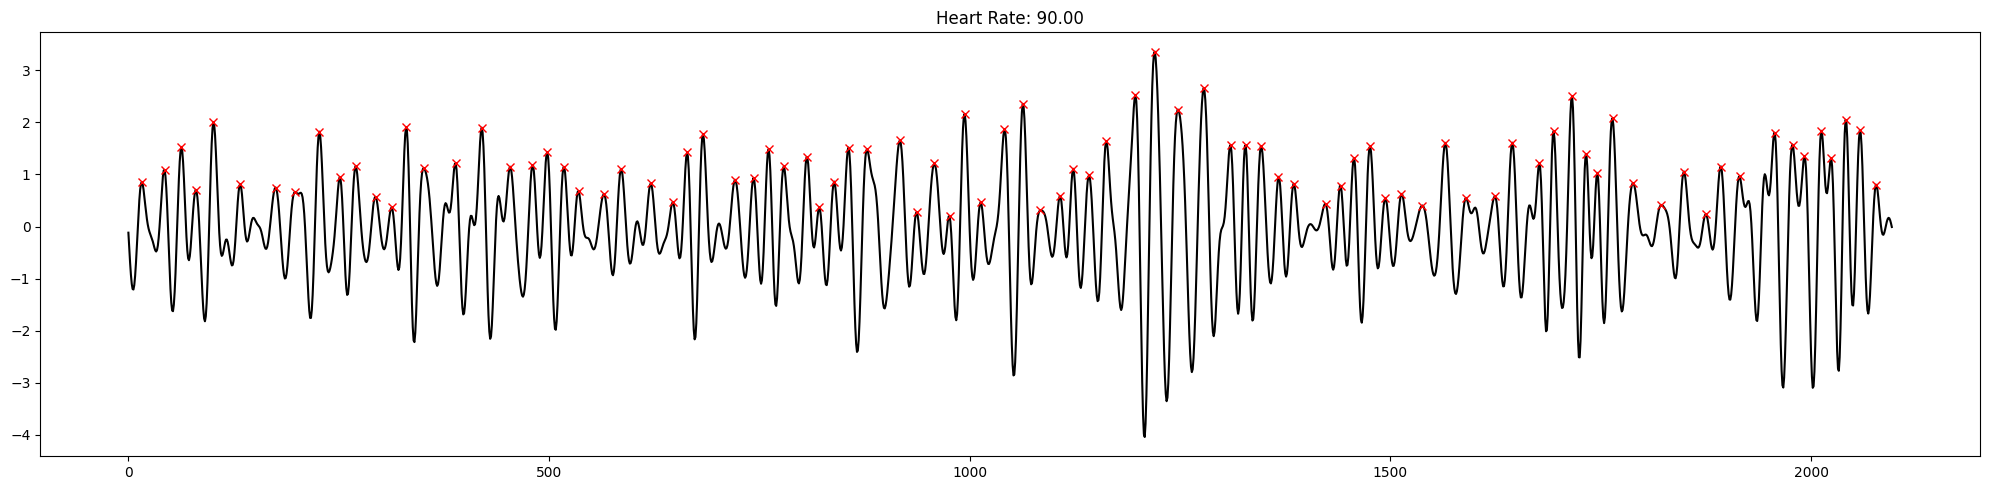

In [17]:
# Memfilter Sinyal rPPG
fs = 35; lowcut = 0.9; highcut = 2.4; order = 3
b, a = signal.butter(order, [lowcut, highcut], btype='band', fs=fs)
filtered_rppg = signal.filtfilt(b, a, rppg_signal)

## Normalizing the signal
filtered_rppg = (filtered_rppg - np.mean(filtered_rppg)) / np.std(filtered_rppg)

fig, ax = plt.subplots(2, 1, figsize=(20, 6))
ax[0].plot(rppg_signal, color='black')
ax[0].set_title('rPPG Signal - Before Filtering')
ax[1].plot(filtered_rppg, color='black')
ax[1].set_title('rPPG Signal - After Filtering')
plt.tight_layout()
plt.show()

# Mencari puncak sinyal
peaks, _ = signal.find_peaks(
    x=filtered_rppg, prominence=0.5
)

# Menghitung heart rate
rr_intervals = np.diff(peaks) / fs
heart_rate = int(60 / np.mean(rr_intervals))

# Menampilkan grafik puncak sinyal
plt.figure(figsize=(20, 5))
plt.plot(filtered_rppg, color='black')
plt.plot(peaks, filtered_rppg[peaks], 'x', color='red')
plt.title(f'Heart Rate: {heart_rate:.2f}')
plt.tight_layout()
plt.show()